In [1]:
import pandas as pd
import glob
import numpy as np
import matplotlib.pyplot as plt
import tqdm
import datetime as dt
from matplotlib.lines import Line2D
from matplotlib.patches import Patch

In [2]:
def read_csv(path):

    df = pd.read_csv(path)
    df["time"] = pd.to_datetime(df["time"])
    df = df.set_index("time").loc[slice("1979-01-01","2024-12-31 23:00")]
    df = df.loc[np.in1d(df.index.month,[12,1,2])]
    return df

bunbury = read_csv("/g/data/ng72/ab4502/sea_breeze_detection/barra_c_smooth_s2/sb_days/bunbury.csv")
gipps = read_csv("/g/data/ng72/ab4502/sea_breeze_detection/barra_c_smooth_s2/sb_days/gipps.csv")
illawara = read_csv("/g/data/ng72/ab4502/sea_breeze_detection/barra_c_smooth_s2/sb_days/illawara.csv")
newcastle = read_csv("/g/data/ng72/ab4502/sea_breeze_detection/barra_c_smooth_s2/sb_days/newcastle.csv")
sa = read_csv("/g/data/ng72/ab4502/sea_breeze_detection/barra_c_smooth_s2/sb_days/sa.csv")
southern = read_csv("/g/data/ng72/ab4502/sea_breeze_detection/barra_c_smooth_s2/sb_days/southern.csv")
tas = read_csv("/g/data/ng72/ab4502/sea_breeze_detection/barra_c_smooth_s2/sb_days/tas.csv")

In [3]:
cf_names = np.sort(glob.glob("/g/data/ng72/ab4502/capacity_factor/hourly_cf_*"))
vp_names = np.sort(glob.glob("/g/data/ng72/ab4502/capacity_factor/hourly_vp850_*"))
up_names = np.sort(glob.glob("/g/data/ng72/ab4502/capacity_factor/hourly_up850_*"))

In [4]:
cf_names = cf_names[np.in1d(np.array([int(f.split("/")[-1].split("_")[-2][4:6]) for f in cf_names]),[1,2,12])]
vp_names = vp_names[np.in1d(np.array([int(f.split("/")[-1].split("_")[-2][4:6]) for f in vp_names]),[1,2,12])]
up_names = up_names[np.in1d(np.array([int(f.split("/")[-1].split("_")[-2][4:6]) for f in up_names]),[1,2,12])]

In [5]:
cf_ls = [pd.read_csv(f) for f in tqdm.tqdm(cf_names)]
vp_ls = [pd.read_csv(f) for f in tqdm.tqdm(vp_names)]
up_ls = [pd.read_csv(f) for f in tqdm.tqdm(up_names)]

100%|██████████| 138/138 [00:00<00:00, 247.71it/s]


In [6]:
cf = pd.concat(cf_ls,axis=0)
cf["AWST"] = pd.to_datetime(cf.time) + dt.timedelta(hours=8)
cf["AEST"] = pd.to_datetime(cf.time) + dt.timedelta(hours=10)

vp = pd.concat(vp_ls,axis=0)
vp["AWST"] = pd.to_datetime(vp.time) + dt.timedelta(hours=8)
vp["AEST"] = pd.to_datetime(vp.time) + dt.timedelta(hours=10)

up = pd.concat(up_ls,axis=0)
up["AWST"] = pd.to_datetime(up.time) + dt.timedelta(hours=8)
up["AEST"] = pd.to_datetime(up.time) + dt.timedelta(hours=10)

In [7]:
sb_date_dict = {
    "gipps":gipps,
    "illawara":illawara,
    "newcastle":newcastle,
    "sa":sa,
    "southern":southern,
    "tas":tas,
    "bunbury_near":bunbury,
    "bunbury_offshore":bunbury}

In [12]:
(np.in1d(cf[tz].dt.date, sb_date_dict[r].query("sb==1").index.date))

array([ True,  True,  True, ..., False, False, False])

In [8]:
cf_on_right_sb_ls = []
cf_off_right_sb_ls = []
cf_on_left_sb_ls = []
cf_off_left_sb_ls = []

for r, tz in zip(["gipps","illawara","newcastle","sa","southern","tas","bunbury_near","bunbury_offshore"],
                 ["AEST","AEST","AEST","AEST","AEST","AEST","AWST","AWST"]):

    print(r)
    
    #Get the daily time series of 5 am vprime (onshore component) and uprime across-shore component
    vp_morn = vp[vp[tz].dt.hour==5]
    up_morn = up[up[tz].dt.hour==5]
    
    #Get dates for onshore/offshore and left/right
    onshore_dates = vp_morn[(vp_morn[r] > 0)][tz].dt.date
    offshore_dates = vp_morn[(vp_morn[r] <= 0)][tz].dt.date
    right_dates = up_morn[(up_morn[r] > 0)][tz].dt.date
    left_dates = up_morn[(up_morn[r] <= 0)][tz].dt.date

    #Get sea breeze dates
    sb_inds = (np.in1d(cf[tz].dt.date, sb_date_dict[r].query("sb==1").index.date))
    
    #Get the hourly time series of CF for each set of dates
    cf_onshore_right = cf[ (np.in1d(cf[tz].dt.date, onshore_dates)) & (np.in1d(cf[tz].dt.date, right_dates)) & sb_inds]
    cf_offshore_right = cf[ (np.in1d(cf[tz].dt.date, offshore_dates)) & (np.in1d(cf[tz].dt.date, right_dates)) & sb_inds]
    cf_onshore_left = cf[ (np.in1d(cf[tz].dt.date, onshore_dates)) & (np.in1d(cf[tz].dt.date, left_dates)) & sb_inds]
    cf_offshore_left = cf[ (np.in1d(cf[tz].dt.date, offshore_dates)) & (np.in1d(cf[tz].dt.date, left_dates)) & sb_inds]
    
    cf_on_right_sb_ls.append(cf_onshore_right[[r,tz]].groupby(cf_onshore_right[tz].dt.hour).mean()[[r]])
    cf_off_right_sb_ls.append(cf_offshore_right[[r,tz]].groupby(cf_offshore_right[tz].dt.hour).mean()[[r]])
    cf_on_left_sb_ls.append(cf_onshore_left[[r,tz]].groupby(cf_onshore_left[tz].dt.hour).mean()[[r]])
    cf_off_left_sb_ls.append(cf_offshore_left[[r,tz]].groupby(cf_offshore_left[tz].dt.hour).mean()[[r]])
    

gipps
illawara
newcastle
sa
southern
tas
bunbury_near
bunbury_offshore


In [9]:
cf_on_right_sb_df = pd.concat(cf_on_right_sb_ls,axis=1)
cf_off_right_sb_df = pd.concat(cf_off_right_sb_ls,axis=1)
cf_on_left_sb_df = pd.concat(cf_on_left_sb_ls,axis=1)
cf_off_left_sb_df = pd.concat(cf_off_left_sb_ls,axis=1)

In [15]:
cf_on_right_nonsb_ls = []
cf_off_right_nonsb_ls = []
cf_on_left_nonsb_ls = []
cf_off_left_nonsb_ls = []

for r, tz in zip(["gipps","illawara","newcastle","sa","southern","tas","bunbury_near","bunbury_offshore"],
                 ["AEST","AEST","AEST","AEST","AEST","AEST","AWST","AWST"]):

    print(r)
    
    #Get the daily time series of 5 am vprime (onshore component) and uprime across-shore component
    vp_morn = vp[vp[tz].dt.hour==5]
    up_morn = up[up[tz].dt.hour==5]
    
    #Get dates for onshore/offshore and left/right
    onshore_dates = vp_morn[(vp_morn[r] > 0)][tz].dt.date
    offshore_dates = vp_morn[(vp_morn[r] <= 0)][tz].dt.date
    right_dates = up_morn[(up_morn[r] > 0)][tz].dt.date
    left_dates = up_morn[(up_morn[r] <= 0)][tz].dt.date

    #Get sea breeze dates
    sb_inds = (np.in1d(cf[tz].dt.date, sb_date_dict[r].query("sb==0").index.date))
    
    #Get the hourly time series of CF for each set of dates
    cf_onshore_right = cf[ (np.in1d(cf[tz].dt.date, onshore_dates)) & (np.in1d(cf[tz].dt.date, right_dates)) & sb_inds]
    cf_offshore_right = cf[ (np.in1d(cf[tz].dt.date, offshore_dates)) & (np.in1d(cf[tz].dt.date, right_dates)) & sb_inds]
    cf_onshore_left = cf[ (np.in1d(cf[tz].dt.date, onshore_dates)) & (np.in1d(cf[tz].dt.date, left_dates)) & sb_inds]
    cf_offshore_left = cf[ (np.in1d(cf[tz].dt.date, offshore_dates)) & (np.in1d(cf[tz].dt.date, left_dates)) & sb_inds]
    
    cf_on_right_nonsb_ls.append(cf_onshore_right[[r,tz]].groupby(cf_onshore_right[tz].dt.hour).mean()[[r]])
    cf_off_right_nonsb_ls.append(cf_offshore_right[[r,tz]].groupby(cf_offshore_right[tz].dt.hour).mean()[[r]])
    cf_on_left_nonsb_ls.append(cf_onshore_left[[r,tz]].groupby(cf_onshore_left[tz].dt.hour).mean()[[r]])
    cf_off_left_nonsb_ls.append(cf_offshore_left[[r,tz]].groupby(cf_offshore_left[tz].dt.hour).mean()[[r]])
    

gipps
illawara
newcastle
sa
southern
tas
bunbury_near
bunbury_offshore


In [16]:
cf_on_right_nonsb_df = pd.concat(cf_on_right_nonsb_ls,axis=1)
cf_off_right_nonsb_df = pd.concat(cf_off_right_nonsb_ls,axis=1)
cf_on_left_nonsb_df = pd.concat(cf_on_left_nonsb_ls,axis=1)
cf_off_left_nonsb_df = pd.concat(cf_off_left_nonsb_ls,axis=1)

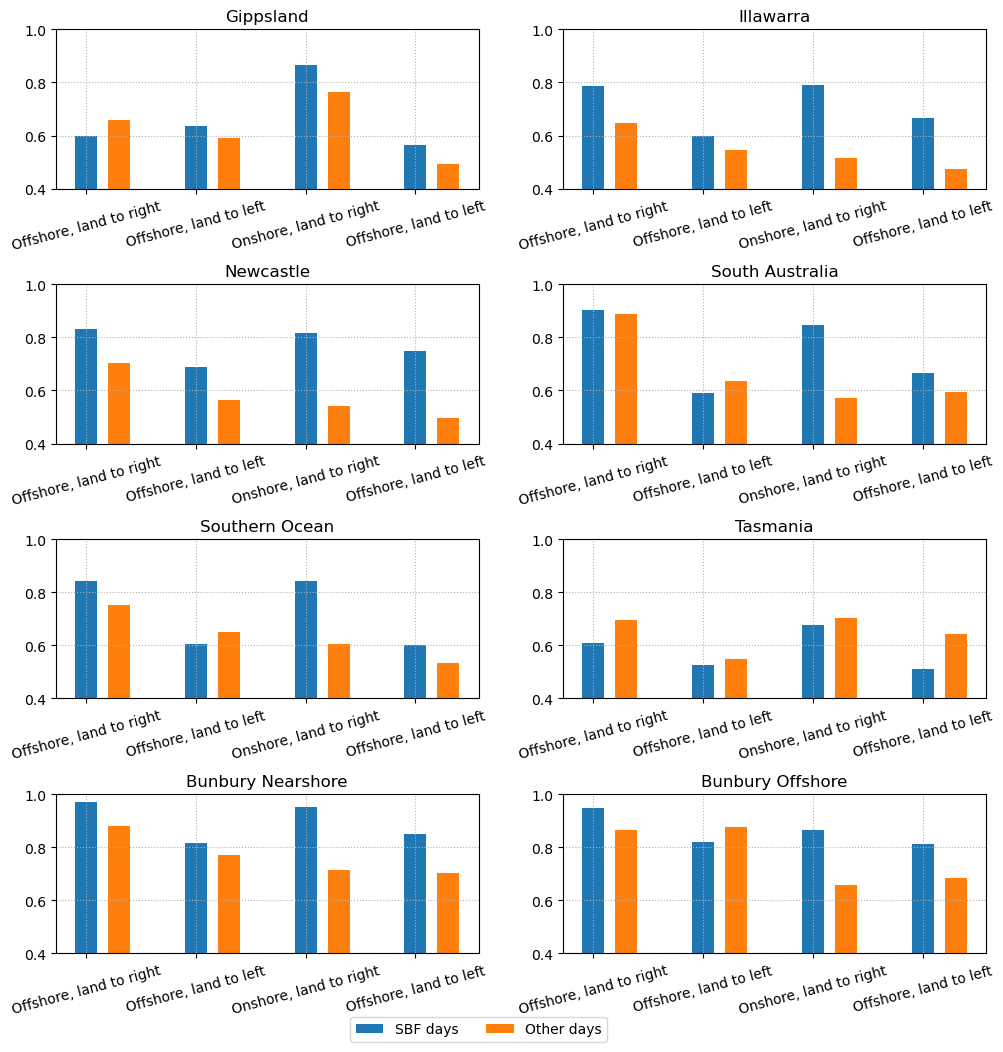

In [71]:
# def plot(r):

#     cf_off_right_df[r].plot(
#         color="tab:blue",label="Offshore, land to the right")
#     cf_off_left_df[r].plot(
#         color="tab:blue",ls=":",label="Offshore, land to the left")
#     cf_on_right_df[r].plot(
#         color="tab:orange",label="Onshore, land to the right")
#     cf_on_left_df[r].plot(
#         color="tab:orange",ls=":",label="Onshore, land to the left")
#     plt.ylim([0.2,1])
#     plt.gca().grid(ls=":")

def plot(r,h=18):
    plt.bar([0,0.3,1,1.3,2,2.3,3,3.3],
            [cf_off_right_sb_df.loc[h,r],
             cf_off_right_nonsb_df.loc[h,r],
             cf_off_left_sb_df.loc[h,r],
             cf_off_left_nonsb_df.loc[h,r],
             cf_on_right_sb_df.loc[h,r],
             cf_on_right_nonsb_df.loc[h,r],
             cf_on_left_sb_df.loc[h,r],
             cf_on_left_nonsb_df.loc[h,r]],width=0.2,
            color=["tab:blue","tab:orange","tab:blue","tab:orange","tab:blue","tab:orange","tab:blue","tab:orange"])
    plt.ylim([0.4,1])    
    plt.title(r)
    plt.xticks([0,1,2,3],
               ["Offshore, land to right","Offshore, land to left","Onshore, land to right","Offshore, land to left"],
              rotation=15)
    plt.gca().grid(ls=":")

fig=plt.figure(figsize=[12,12])

ax=plt.subplot(4,2,1)
plot("gipps")
plt.title("Gippsland")

ax=plt.subplot(4,2,2)
plot("illawara")
plt.title("Illawarra")

ax=plt.subplot(4,2,3)
plot("newcastle")
plt.title("Newcastle")

ax=plt.subplot(4,2,4)
plot("sa")
plt.title("South Australia")

ax=plt.subplot(4,2,5)
plot("southern")
plt.title("Southern Ocean")

ax=plt.subplot(4,2,6)
plot("tas")
plt.title("Tasmania")

ax=plt.subplot(4,2,7)
plot("bunbury_near")
plt.title("Bunbury Nearshore")

ax=plt.subplot(4,2,8)
plot("bunbury_offshore")
plt.title("Bunbury Offshore")

plt.subplots_adjust(hspace=0.6)

legend_elements = [Patch(facecolor='tab:blue', label='SBF days'),
                   Patch(facecolor='tab:orange', label='Other days')]
plt.legend(handles=legend_elements,loc="lower center",bbox_to_anchor=[-0.2,-0.6],ncols=2)

plt.savefig("/g/data/ng72/ab4502/figs/wind_energy_paper/cf_sb_days_prevailing.jpeg",bbox_inches="tight",dpi=300)

In [49]:
sb_freq_on_right_ls = []
sb_freq_off_right_ls = []
sb_freq_on_left_ls = []
sb_freq_off_left_ls = []

for r, tz in zip(["gipps","illawara","newcastle","sa","southern","tas","bunbury_near","bunbury_offshore"],
                 ["AEST","AEST","AEST","AEST","AEST","AEST","AWST","AWST"]):

    print(r)
    
    #Get the daily time series of 5 am vprime (onshore component) and uprime across-shore component
    vp_morn = vp[vp[tz].dt.hour==5]
    up_morn = up[up[tz].dt.hour==5]
    
    #Get dates for onshore/offshore and left/right
    onshore_dates = vp_morn[(vp_morn[r] > 0)][tz].dt.date
    offshore_dates = vp_morn[(vp_morn[r] <= 0)][tz].dt.date
    right_dates = up_morn[(up_morn[r] > 0)][tz].dt.date
    left_dates = up_morn[(up_morn[r] <= 0)][tz].dt.date

      
    sb_freq_on_right_ls.append(
        sb_date_dict[r].loc[
        np.in1d(sb_date_dict[r].index.date,onshore_dates) & np.in1d(sb_date_dict[r].index.date,right_dates)
        ].mean().values[0])
    sb_freq_off_right_ls.append(
        sb_date_dict[r].loc[
        np.in1d(sb_date_dict[r].index.date,offshore_dates) & np.in1d(sb_date_dict[r].index.date,right_dates)
        ].mean().values[0])
    sb_freq_on_left_ls.append(
        sb_date_dict[r].loc[
        np.in1d(sb_date_dict[r].index.date,onshore_dates) & np.in1d(sb_date_dict[r].index.date,left_dates)
        ].mean().values[0])
    sb_freq_off_left_ls.append(
        sb_date_dict[r].loc[
        np.in1d(sb_date_dict[r].index.date,offshore_dates) & np.in1d(sb_date_dict[r].index.date,left_dates)
        ].mean().values[0])
    
    

gipps
illawara
newcastle
sa
southern
tas
bunbury_near
bunbury_offshore


In [60]:
sb_freq_on_right_df = pd.DataFrame(sb_freq_on_right_ls,index=["gipps","illawara","newcastle","sa","southern","tas","bunbury_near","bunbury_offshore"]).T
sb_freq_off_right_df = pd.DataFrame(sb_freq_off_right_ls,index=["gipps","illawara","newcastle","sa","southern","tas","bunbury_near","bunbury_offshore"]).T
sb_freq_on_left_df = pd.DataFrame(sb_freq_on_left_ls,index=["gipps","illawara","newcastle","sa","southern","tas","bunbury_near","bunbury_offshore"]).T
sb_freq_off_left_df = pd.DataFrame(sb_freq_off_left_ls,index=["gipps","illawara","newcastle","sa","southern","tas","bunbury_near","bunbury_offshore"]).T



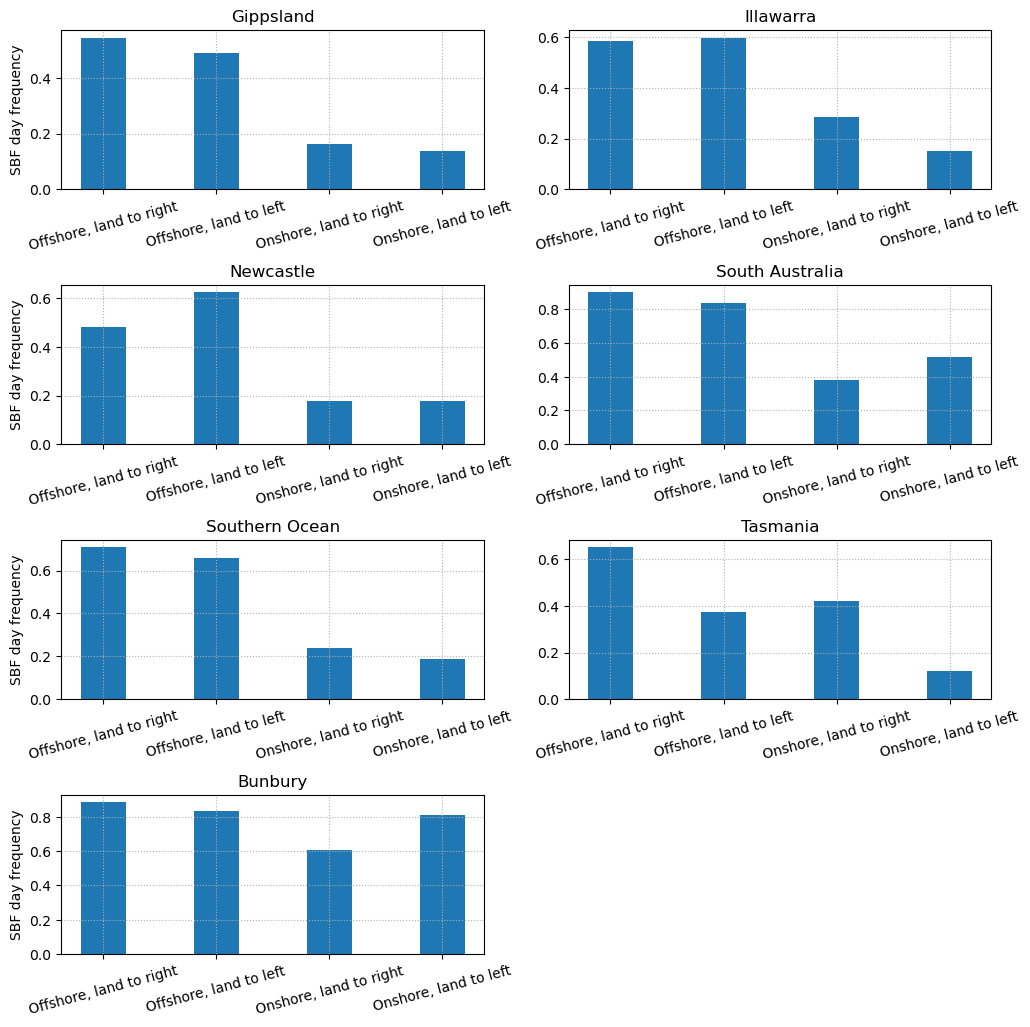

In [70]:
# def plot(r):

#     cf_off_right_df[r].plot(
#         color="tab:blue",label="Offshore, land to the right")
#     cf_off_left_df[r].plot(
#         color="tab:blue",ls=":",label="Offshore, land to the left")
#     cf_on_right_df[r].plot(
#         color="tab:orange",label="Onshore, land to the right")
#     cf_on_left_df[r].plot(
#         color="tab:orange",ls=":",label="Onshore, land to the left")
#     plt.ylim([0.2,1])
#     plt.gca().grid(ls=":")

def plot(r):
    plt.bar([0,1,2,3],
            [sb_freq_off_right_df[r].values[0],
            sb_freq_off_left_df[r].values[0],
            sb_freq_on_right_df[r].values[0],
            sb_freq_on_left_df[r].values[0]],width=0.4)
    plt.title(r)
    plt.xticks([0,1,2,3],
               ["Offshore, land to right","Offshore, land to left","Onshore, land to right","Onshore, land to left"],
              rotation=15)
    plt.gca().grid(ls=":")

fig=plt.figure(figsize=[12,12])

ax=plt.subplot(4,2,1)
plot("gipps")
plt.title("Gippsland")
plt.ylabel("SBF day frequency")

ax=plt.subplot(4,2,2)
plot("illawara")
plt.title("Illawarra")

ax=plt.subplot(4,2,3)
plot("newcastle")
plt.title("Newcastle")
plt.ylabel("SBF day frequency")

ax=plt.subplot(4,2,4)
plot("sa")
plt.title("South Australia")

ax=plt.subplot(4,2,5)
plot("southern")
plt.title("Southern Ocean")
plt.ylabel("SBF day frequency")

ax=plt.subplot(4,2,6)
plot("tas")
plt.title("Tasmania")

ax=plt.subplot(4,2,7)
plot("bunbury_near")
plt.title("Bunbury")
plt.ylabel("SBF day frequency")


plt.subplots_adjust(hspace=0.6)

# legend_elements = [Patch(facecolor='tab:blue', label='SBF days'),
#                    Patch(facecolor='tab:orange', label='Other days')]
# plt.legend(handles=legend_elements,loc="lower center",bbox_to_anchor=[-0.2,-0.6],ncols=2)

plt.savefig("/g/data/ng72/ab4502/figs/wind_energy_paper/sbf_freq_prevailing.jpeg",bbox_inches="tight",dpi=300)